In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd drive/MyDrive/DATA

/content/drive/MyDrive/DATA


In [ ]:
!pip install --quiet pandas scikit-learn tqdm sentence-transformers python-Levenshtein rapidfuzz scikit-learn-extra optuna
!pip install -q kmedoids

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 12.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 476.3/476.3 kB 12.5 MB/s eta 0:00:00


In [ ]:
import os
import re
import numpy as np
import pandas as pd
from tqdm import tqdm
import optuna

from kmedoids import KMedoids
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

# Пути
INPUT_CSV = "frccsc_processed.csv"
OUTPUT_DIR = "path_processed2"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Параметры
K_MIN = 2
K_MAX = 200
SIL_STEP = 1
RANDOM_STATE = 42

# Базовые значения (позже подбираются через Optuna)
MW = 3.0
DIST_THRESHOLD = 5.0

mode = 2
BERT_MODE = 1

# Параметры Optuna
OPTUNA_TRIALS = 20
TUNE_SAMPLE_SIZE = 1500
OPTUNA_TIMEOUT = None

In [ ]:

df = pd.read_csv(INPUT_CSV)
print("Загружено строк:", len(df))

if "WorkDir" not in df.columns:
    raise ValueError("Входной CSV должен содержать столбец WorkDir")

paths_full = df["WorkDir"].fillna("").astype(str)

# Уникальные пути сохраняем для BERT и возможной последующей агрегации
unique_paths_df = df[["WorkDir"]].drop_duplicates().reset_index(drop=False)
unique_paths_df.rename(columns={"index": "OrigIndex"}, inplace=True)
unique_paths_df["WorkDir"] = unique_paths_df["WorkDir"].astype(str)

# PREP: работаем со всеми путями (mode=2)
if mode == 1:
    paths = unique_paths_df["WorkDir"]
else:
    paths = paths_full

# BERT: сохраняем исходную логику на уникальных путях
#bert_paths = unique_paths_df["WorkDir"].fillna("").astype(str)
bert_paths = paths_full


Загружено строк: 13460


In [ ]:
def r2_score_from_clusters(y_true, labels):
    y_true = np.asarray(y_true, dtype=float)
    labels = np.asarray(labels)
    n = len(y_true)
    if n < 3:
        return -np.inf

    unique_labels = np.unique(labels)
    p = max(1, len(unique_labels) - 1)

    if len(unique_labels) <= 1 or n <= p + 1:
        return -np.inf

    X = pd.get_dummies(labels.astype(str), drop_first=True)
    if X.shape[1] == 0:
        return -np.inf

    X_mat = np.column_stack([np.ones(n), X.values.astype(float)])
    try:
        beta, *_ = np.linalg.lstsq(X_mat, y_true, rcond=None)
        y_pred = X_mat @ beta
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        if ss_tot <= 0:
            return -np.inf
        r2 = 1.0 - ss_res / ss_tot
        return float(r2)
    except Exception:
        return -np.inf


def find_best_k_by_silhouette(D, k_min=K_MIN, k_max=K_MAX, step=SIL_STEP):
    best_k = None
    best_score = -1.0
    n = D.shape[0]
    k_upper = min(k_max, max(2, n - 1))

    for k in range(k_min, k_upper + 1, step):
        if k >= n:
            break
        try:
            model = KMedoids(
                n_clusters=k,
                metric="precomputed",
                method="fasterpam",
                init="random",
                random_state=RANDOM_STATE
            )
            labels = model.fit_predict(D)

            if len(np.unique(labels)) <= 1:
                continue

            score = silhouette_score(D, labels, metric="precomputed")

            if score > best_score:
                best_score = score
                best_k = k
        except Exception:
            continue

    if best_k is None:
        best_k = 1
        best_score = np.nan

    return best_k, best_score

In [ ]:
def propagate_labels_to_full_df(df_full, unique_paths_df, labels_unique):
    """
    df_full — исходный DataFrame (13 460 строк)
    unique_paths_df — таблица уникальных путей с колонкой OrigIndex
    labels_unique — метки кластеров для уникальных WorkDir
    """

    # создаём таблицу WorkDir → ClusterID
    unique_paths_df["ClusterID"] = labels_unique
    cluster_map = dict(zip(unique_paths_df["WorkDir"], unique_paths_df["ClusterID"]))

    # распространение меток на весь DataFrame
    df_full["PathClusterID"] = df_full["WorkDir"].map(cluster_map)

    return df_full


In [ ]:

def normalize_path(path: str) -> str:
    return str(path).strip()


def split_path(path: str):
    """
    Разбиение пути на подстроки.
    """
    parts = [p for p in normalize_path(path).strip("/").split("/") if p]
    if len(parts) >= 2:
        return parts[2:], parts[1]
    if len(parts) >= 1:
        return parts[1:], parts[0]
    return [], ""


def refine_path(path: str) -> str:
    """
    Удаляем цифры и специальные символы,
    переводим буквы в нижний регистр.
    """
    raw_parts = [p for p in normalize_path(path).strip("/").split("/") if p]
    refined_parts = []
    for part in raw_parts:
        cleaned = re.sub(r"[^a-zA-Z]+", "", part).lower()
        if cleaned:
            refined_parts.append(cleaned)
    return "/" + "/".join(refined_parts)


def extract_user_from_path(path: str) -> str:
    parts = [p for p in normalize_path(path).strip("/").split("/") if p]
    if len(parts) >= 2 and parts[0].lower() == "home":
        return parts[1]
    return parts[0] if parts else ""


In [ ]:
def build_distance_matrix(parts_list, MW=MW, show_progress=False):
    """
    Создаёт матрицу попарных расстояний (n × n) для списка путей одного пользователя.
    """
    n = len(parts_list)
    D = np.zeros((n, n), dtype=float)

    rng = tqdm(range(n), desc="pairwise") if show_progress else range(n)

    for i in rng:
        for j in range(i + 1, n):
            d = weighted_path_distance(parts_list[i], parts_list[j], MW=MW)
            D[i, j] = d
            D[j, i] = d

    return D


def connected_components_from_binary_similarity(S):
    """
    Связные компоненты графа похожих путей.
    """
    n = S.shape[0]
    labels = -np.ones(n, dtype=int)
    cur = 0

    for start in range(n):
        if labels[start] != -1:
            continue

        neighbors = np.where(S[start] == 1)[0]

        if len(neighbors) == 1 and neighbors[0] == start:
            continue

        q = deque([start])
        labels[start] = cur

        while q:
            v = q.popleft()
            neighbors = np.where(S[v] == 1)[0]
            for u in neighbors:
                if labels[u] == -1:
                    labels[u] = cur
                    q.append(u)

        cur += 1

    return labels

def cluster_paths_prep_kmedoids(paths_series, uid_series, MW=MW, k_min=K_MIN, k_max=K_MAX, step=SIL_STEP, show_progress=False):
    """
    Реализация PREP с матрицами расстояний и K-Means,
    где K выбирается методом силуэта отдельно для каждого пользователя.
    """
    work = pd.DataFrame({
        "WorkDir": paths_series.fillna("").astype(str),
        "UserKey": uid_series.fillna(-1).astype(str)
    })

    global_labels = np.full(len(work), -1, dtype=int)
    silhouette_by_user = {}
    k_by_user = {}
    cluster_offset = 0

    groups = work.groupby("UserKey", sort=False).groups
    iterator = tqdm(groups.items(), total=len(groups), desc="PREP-KMedoids users") if show_progress else groups.items()

    for user_key, idx in iterator:
        idx = list(idx)
        user_paths = work.loc[idx, "WorkDir"].tolist()
        parts_list = [split_path(p)[0] for p in user_paths]
        n = len(parts_list)

        if n == 1:
            local_labels = np.array([0], dtype=int)
            best_k = 1
            best_score = np.nan
        else:
            D = build_distance_matrix(parts_list, MW=MW, show_progress=False)
            best_k, best_score = find_best_k_by_silhouette(D, k_min=k_min, k_max=k_max, step=step)
            if best_k is None or best_k < 1:
                best_k = 1
            if best_k == 1 or n < 2:
                local_labels = np.zeros(n, dtype=int)
            else:
                model = KMedoids(
                    n_clusters=best_k,
                    metric="precomputed",
                    method="fasterpam",
                    init="random",
                    random_state=RANDOM_STATE
                )
                local_labels = model.fit_predict(D)

        silhouette_by_user[user_key] = best_score
        k_by_user[user_key] = best_k
        global_labels[idx] = local_labels + cluster_offset
        cluster_offset += int(local_labels.max()) + 1

    return global_labels, k_by_user, silhouette_by_user


def cluster_paths_prep_binary(paths_series, uid_series, MW=MW, threshold=DIST_THRESHOLD, show_progress=False):
    """
    Реализация PREP с refinement и 0-1 матрицей.
    """
    work = pd.DataFrame({
        "WorkDir": paths_series.fillna("").astype(str),
        "UserKey": uid_series.fillna(-1).astype(str)
    })
    work["RefinedPath"] = work["WorkDir"].apply(refine_path)

    global_labels = np.full(len(work), -1, dtype=int)
    cluster_offset = 0
    n_clusters_by_user = {}

    groups = work.groupby("UserKey", sort=False).groups
    iterator = tqdm(groups.items(), total=len(groups), desc="PREP-0/1 users") if show_progress else groups.items()

    for user_key, idx in iterator:
        idx = list(idx)
        user_paths = work.loc[idx, "RefinedPath"].tolist()
        parts_list = [split_path(p)[0] for p in user_paths]
        n = len(parts_list)

        if n == 1:
            local_labels = np.array([0], dtype=int)
        else:
            D = build_distance_matrix(parts_list, MW=MW, show_progress=False)
            similar = (D < threshold).astype(int)
            np.fill_diagonal(similar, 1)
            local_labels = connected_components_from_binary_similarity(similar)

            if np.any(local_labels == -1):
                next_label = local_labels.max() + 1
                local_labels[local_labels == -1] = next_label

        print(user_key)
        print(local_labels, end='\n\n')

        n_clusters_by_user[user_key] = int(local_labels.max()) + 1
        global_labels[idx] = local_labels + cluster_offset
        cluster_offset += int(local_labels.max()) + 1

    return global_labels, n_clusters_by_user


def sample_for_optuna(df_full, sample_size=TUNE_SAMPLE_SIZE, random_state=RANDOM_STATE):
    cols = ["WorkDir", "UID" , "ElapsedRaw"]
    tune_df = df_full[cols].dropna().copy()
    if len(tune_df) > sample_size:
        tune_df = tune_df.sample(sample_size, random_state=random_state)
    tune_df = tune_df.reset_index(drop=True)
    return tune_df


def tune_prep_binary_params(df_full, n_trials=OPTUNA_TRIALS, timeout=OPTUNA_TIMEOUT):
    tune_df = sample_for_optuna(df_full)
    y = tune_df["ElapsedRaw"].astype(float).values
    paths_tune = tune_df["WorkDir"].fillna("").astype(str)

    def objective(trial):
        mw = trial.suggest_int("MW", 2, 6)
        threshold = trial.suggest_int("DIST_THRESHOLD", 3, 7)
        try:
            labels, _ = cluster_paths_prep_binary(
                paths_tune,
                tune_df["UID"],
                MW=mw,
                threshold=threshold,
                show_progress=False,
            )
            score = r2_score_from_clusters(y, labels)
            if not np.isfinite(score):
                return -1e9
            return score
        except Exception:
            return -1e9

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials, timeout=timeout, show_progress_bar=False)
    return study.best_params, study.best_value

In [ ]:
print("[Optuna] Подбор гиперпараметров PREP")

best_params_prep_01, best_value_prep_01 = tune_prep_binary_params(
    df,
    n_trials=OPTUNA_TRIALS,
    timeout=OPTUNA_TIMEOUT
)
BEST_MW_PREP = float(best_params_prep_01["MW"])
BEST_DIST_THRESHOLD = float(best_params_prep_01["DIST_THRESHOLD"])

print(f"PREP 0-1 matrix: best MW = {BEST_MW_PREP:.4f}, best DIST_THRESHOLD = {BEST_DIST_THRESHOLD:.4f}, objective = {best_value_prep_01:.4f}")

[I 2026-03-31 20:52:36,233] A new study created in memory with name: no-name-8ea53d57-07dc-4006-be89-316dcc4c12e5


[Optuna] Подбор гиперпараметров PREP


[I 2026-03-31 20:52:36,263] Trial 0 finished with value: -1000000000.0 and parameters: {'MW': 5, 'DIST_THRESHOLD': 3}. Best is trial 0 with value: -1000000000.0.
[I 2026-03-31 20:52:36,289] Trial 1 finished with value: -1000000000.0 and parameters: {'MW': 2, 'DIST_THRESHOLD': 7}. Best is trial 0 with value: -1000000000.0.
[I 2026-03-31 20:52:36,313] Trial 2 finished with value: -1000000000.0 and parameters: {'MW': 4, 'DIST_THRESHOLD': 3}. Best is trial 0 with value: -1000000000.0.
[I 2026-03-31 20:52:36,340] Trial 3 finished with value: -1000000000.0 and parameters: {'MW': 6, 'DIST_THRESHOLD': 4}. Best is trial 0 with value: -1000000000.0.
[I 2026-03-31 20:52:36,370] Trial 4 finished with value: -1000000000.0 and parameters: {'MW': 4, 'DIST_THRESHOLD': 5}. Best is trial 0 with value: -1000000000.0.
[I 2026-03-31 20:52:36,391] Trial 5 finished with value: -1000000000.0 and parameters: {'MW': 3, 'DIST_THRESHOLD': 6}. Best is trial 0 with value: -1000000000.0.
[I 2026-03-31 20:52:36,414] 

PREP 0-1 matrix: best MW = 5.0000, best DIST_THRESHOLD = 3.0000, objective = -1000000000.0000


In [ ]:

def weighted_path_distance(parts_a, parts_b, MW=MW):
    """
    Dis(a,b) = sum_i sum_j LD(a_i, b_j) * max(weight_i, weight_j)
    где веса убывают от начала пользовательской части пути к концу.
    """

    la = len(parts_a)
    lb = len(parts_b)

    if la == 0 and lb == 0:
        return 0.0
    if la == 0:
        w_b = compute_weights(lb, MW=MW)
        return float(sum(ld("", b_j) * w_b[j] for j, b_j in enumerate(parts_b)))
    if lb == 0:
        w_a = compute_weights(la, MW=MW)
        return float(sum(ld(a_i, "") * w_a[i] for i, a_i in enumerate(parts_a)))

    w_a = compute_weights(la, MW=MW)
    w_b = compute_weights(lb, MW=MW)

    s = 0.0
    for i, a_i in enumerate(parts_a):
        for j, b_j in enumerate(parts_b):
            s += ld(a_i, b_j) * max(w_a[i], w_b[j])
    return float(s)


In [ ]:

def compute_weights(n_parts, MW=MW):
    """
    weight_i = MW - ((i - 1)(MW - 1)) / (n - 1),  i = 1..n
    где первый элемент имеет максимальный вес, последний — вес 1.
    """
    if n_parts <= 0:
        return []
    if n_parts == 1:
        return [MW]
    return [MW - (i * (MW - 1.0) / (n_parts - 1)) for i in range(n_parts)]


In [ ]:

# Импорты для PREP
from collections import defaultdict, deque
import Levenshtein


def ld(a, b):
    return Levenshtein.distance(a, b)


In [ ]:
print("[1] PREP: K-Means + метод силуэта")

labels_prep_kmeans, prep_kmeans_k_by_user, prep_kmeans_sc_by_user = cluster_paths_prep_kmedoids(
    paths,
    df["UID"],
    MW=BEST_MW_PREP,
    k_min=K_MIN,
    k_max=K_MAX,
    step=SIL_STEP,
    show_progress=False,
)

best_k_prep_kmeans = int(len(np.unique(labels_prep_kmeans)))
valid_sc = [v for v in prep_kmeans_sc_by_user.values() if v is not None and not pd.isna(v)]
best_score_prep_kmeans = float(np.mean(valid_sc)) if len(valid_sc) > 0 else np.nan

print(f"Подобранный MW: {BEST_MW_PREP:.4f}")
print(f"Число глобальных кластеров: {best_k_prep_kmeans}")
print(f"Средний user-specific silhouette: {best_score_prep_kmeans:.4f}")

if mode == 1:
    df_prep_kmeans = propagate_labels_to_full_df(df.copy(), unique_paths_df.copy(), labels_prep_kmeans)
else:
    df_prep_kmeans = df.copy()
    df_prep_kmeans["PathClusterID"] = labels_prep_kmeans

output_prep_kmeans = os.path.join(OUTPUT_DIR, "frccsc_processed_prep_kmeans.csv")
df_prep_kmeans.to_csv(output_prep_kmeans, index=False)

print("Файл сохранён:", output_prep_kmeans)

[1] PREP: K-Means + метод силуэта
Подобранный MW: 5.0000
Число глобальных кластеров: 1010
Средний user-specific silhouette: 0.3844
Файл сохранён: path_processed2/frccsc_processed_prep_kmeans.csv


In [ ]:
print("[2] PREP: refinement + 0-1 matrix")

labels_prep_01, prep_01_clusters_by_user = cluster_paths_prep_binary(
    paths,
    df["UID"],
    MW=BEST_MW_PREP,
    threshold=BEST_DIST_THRESHOLD,
    show_progress=False,
)

best_k_prep_01 = int(len(np.unique(labels_prep_01)))
best_score_prep_01 = np.nan

print(f"Подобранный MW: {BEST_MW_PREP:.4f}")
print(f"Подобранный порог похожести: {BEST_DIST_THRESHOLD:.4f}")
print(f"Число глобальных кластеров: {best_k_prep_01}")

if mode == 1:
    df_prep_01 = propagate_labels_to_full_df(df.copy(), unique_paths_df.copy(), labels_prep_01)
else:
    df_prep_01 = df.copy()
    df_prep_01["PathClusterID"] = labels_prep_01

output_prep_01 = os.path.join(OUTPUT_DIR, "frccsc_processed_prep_01.csv")
df_prep_01.to_csv(output_prep_01, index=False)

print("Файл сохранён:", output_prep_01)

[2] PREP: refinement + 0-1 matrix
1019
[0 0 2 ... 2 2 2]

1107
[0 0 0 ... 0 0 0]

1157
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0]

0
[0 0 0]

1179
[1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1]

1167
[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 0 0 0 2 2 2 2 2 2 1 1 1 1 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]

1178
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

1126
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from tqdm import tqdm

def path_to_spaced_text(path: str) -> str:
    """
    Преобразует путь в строку токенов, разделённых пробелами.
    Пример:
    "/home/user/work/1" -> "home user work 1"
    """
    parts = [p.strip() for p in str(path).split("/") if p.strip()]
    return " ".join(parts)

def find_best_k_by_silhouette_bert(X, k_min=2, k_max=20, step=1, random_state=42):
    """
    Подбирает оптимальное число кластеров по максимуму silhouette score.
    """
    n = len(X)

    if n <= 1:
        return 1, np.nan

    if n == 2:
        return 2, np.nan

    upper_k = min(k_max, n - 1)
    best_k = None
    best_score = -1.0

    for k in range(k_min, upper_k + 1, step):
        model = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        labels = model.fit_predict(X)

        if len(np.unique(labels)) <= 1:
            continue

        score = silhouette_score(X, labels)

        if score > best_score:
            best_score = score
            best_k = k

    if best_k is None:
        return 1, np.nan

    return best_k, best_score

def cluster_paths_bert_by_user(
    paths_series,
    uid_series,
    model_name="all-MiniLM-L6-v2",
    k_min=2,
    k_max=20,
    step=1,
    random_state=42,
    batch_size=64,
    show_progress=True
):
    """
    Кластеризация путей с помощью BERT отдельно для каждого пользователя.

    В этой версии используются все пути пользователя, без удаления дублей.

    Логика:
    1. Для каждого пользователя берутся все его пути.
    2. Пути преобразуются в текст с пробелами вместо "/".
    3. Для всех путей пользователя считаются BERT-эмбеддинги.
    4. По эмбеддингам подбирается лучшее число кластеров по silhouette score.
    5. Выполняется K-Means-кластеризация.
    6. Локальные метки пользователя переводятся в глобальные через cluster_offset.

    Возвращает:
    - global_labels: глобальные метки кластеров для всех строк;
    - n_clusters_by_user: число кластеров для каждого пользователя;
    - silhouette_by_user: лучшее значение silhouette score для каждого пользователя.
    """
    work = pd.DataFrame({
        "WorkDir": paths_series.fillna("").astype(str),
        "UserKey": uid_series.fillna(-1).astype(str)
    })

    model = SentenceTransformer(model_name)

    global_labels = np.full(len(work), -1, dtype=int)
    cluster_offset = 0
    n_clusters_by_user = {}
    silhouette_by_user = {}

    groups = work.groupby("UserKey", sort=False).groups
    iterator = tqdm(groups.items(), total=len(groups), desc="BERT users") if show_progress else groups.items()

    for user_key, idx in iterator:
        idx = list(idx)
        user_paths = work.loc[idx, "WorkDir"].tolist()
        user_texts = [path_to_spaced_text(p) for p in user_paths]

        if len(user_texts) == 1:
            local_labels = np.array([0], dtype=int)
            best_k = 1
            best_score = np.nan

        else:
            embeddings = model.encode(
                user_texts,
                show_progress_bar=False,
                batch_size=batch_size
            )
            X_user = np.array(embeddings)

            best_k, best_score = find_best_k_by_silhouette_bert(
                X_user,
                k_min=k_min,
                k_max=k_max,
                step=step,
                random_state=random_state
            )

            if best_k == 1:
                local_labels = np.zeros(len(user_texts), dtype=int)
            else:
                km = KMeans(
                    n_clusters=best_k,
                    random_state=random_state,
                    n_init=10
                )
                local_labels = km.fit_predict(X_user)

        n_user_clusters = int(local_labels.max()) + 1
        global_labels[idx] = local_labels + cluster_offset

        n_clusters_by_user[user_key] = n_user_clusters
        silhouette_by_user[user_key] = best_score

        cluster_offset += n_user_clusters

    return global_labels, n_clusters_by_user, silhouette_by_user

In [ ]:

print("[3] BERT-кластеризация по пользователям")

labels_bert, bert_clusters_by_user, bert_silhouette_by_user = cluster_paths_bert_by_user(
    bert_paths,
    df["UID"],
    model_name="all-MiniLM-L6-v2",
    k_min=2,
    k_max=50,
    step=1,
    random_state=RANDOM_STATE,
    batch_size=64,
    show_progress=True
)

print(f"Оптимальное число кластеров: {len(np.unique(labels_bert))}")

df_bert = df.copy()
df_bert["PathClusterID"] = labels_bert

output_bert = os.path.join(OUTPUT_DIR, "frccsc_processed_bert.csv")
df_bert.to_csv(output_bert, index=False)

print("Файл сохранён:", output_bert)


[3] BERT-кластеризация по пользователям


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
BERT users: 100%|██████████| 57/57 [24:19<00:00, 25.60s/it]


Оптимальное число кластеров: 539
Файл сохранён: path_processed2/frccsc_processed_bert.csv


In [ ]:
# СВОДКА
summary = pd.DataFrame({
    "Метод": ["PREP (K-Means+Silhouette)", "PREP (0-1 matrix)", "BERT"],
    "Число кластеров": [best_k_prep_kmeans, best_k_prep_01, best_k_bert],
    "Silhouette Score": [best_score_prep_kmeans, best_score_prep_01, best_score_bert],
    "MW": [BEST_MW_PREP, BEST_MW_PREP, np.nan],
    "DIST_THRESHOLD": [np.nan, BEST_DIST_THRESHOLD, np.nan]
})
print(summary)

NameError: name 'best_k_bert' is not defined

In [ ]:
# ============================================
# ОЦЕНКА КАЧЕСТВА КЛАСТЕРИЗАЦИИ ПО ВРЕМЕНИ ВЫПОЛНЕНИЯ
# ============================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mutual_info_score, silhouette_score, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from scipy.stats import f_oneway, kruskal

# ------------------------------
# Конфигурация
# ------------------------------
INPUT_DIR = "path_processed"

FILES = {
    "PREP (K-Means+Silhouette)": os.path.join(INPUT_DIR, "frccsc_processed_prep_kmeans.csv"),
    "PREP (0-1 matrix)": os.path.join(INPUT_DIR, "frccsc_processed_prep_01.csv"),
    "BERT": os.path.join(INPUT_DIR, "frccsc_processed_bert.csv"),
}

TIME_COL = "ElapsedRaw"
CLUSTER_COL = "PathClusterID"

# для бутстрапа
N_BOOTSTRAP = 50
SAMPLE_FRAC = 0.7
RANDOM_STATE = 42
N_BINS_MI = 10

rng = np.random.default_rng(RANDOM_STATE)


def compute_cluster_stats(df, time_col=TIME_COL, cluster_col=CLUSTER_COL):
    tmp = df[[cluster_col, time_col]].dropna()
    grouped = tmp.groupby(cluster_col)[time_col]

    stats = grouped.agg(["count", "mean", "std", "var", "min", "max"]).rename(
        columns={
            "count": "size",
            "mean": "mean_time",
            "std": "std_time",
            "var": "var_time",
            "min": "min_time",
            "max": "max_time",
        }
    )
    stats["cv_time"] = stats["std_time"] / stats["mean_time"].replace(0, np.nan)
    return stats.reset_index()


def compute_global_metrics(df, time_col=TIME_COL, cluster_col=CLUSTER_COL, n_bins_mi=N_BINS_MI):
    df = df[[time_col, cluster_col]].dropna().copy()
    if df.empty:
        return None, None

    y = df[time_col].values.astype(float)
    labels = df[cluster_col].values
    unique_clusters = np.unique(labels)
    n_clusters = len(unique_clusters)

    cl_stats = compute_cluster_stats(df, time_col, cluster_col)
    mean_intra_var = cl_stats["var_time"].mean()
    weights = cl_stats["size"].values
    weighted_mean_intra_var = np.average(cl_stats["var_time"].fillna(0).values, weights=weights)

    X_time = y.reshape(-1, 1)
    silhouette_time = None
    if n_clusters > 1 and len(df) > n_clusters:
        try:
            silhouette_time = silhouette_score(X_time, labels)
        except Exception:
            silhouette_time = None

    groups = [df.loc[df[cluster_col] == c, time_col].values for c in unique_clusters]
    anova_F, anova_p = None, None
    try:
        anova_F, anova_p = f_oneway(*groups)
    except Exception:
        pass

    kruskal_H, kruskal_p = None, None
    try:
        kruskal_H, kruskal_p = kruskal(*groups)
    except Exception:
        pass

    encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    X_clusters = encoder.fit_transform(labels.reshape(-1, 1))

    reg = LinearRegression()
    try:
        reg.fit(X_clusters, y)
        y_pred = reg.predict(X_clusters)
        r2 = r2_score(y, y_pred)
    except Exception:
        r2 = None

    mi = None
    try:
        df["time_bin"] = pd.qcut(df[time_col], q=n_bins_mi, duplicates="drop")
        time_bins = df["time_bin"].cat.codes.values
        mi = mutual_info_score(labels, time_bins)
    except Exception:
        mi = None

    metrics = {
        "n_clusters": n_clusters,
        "mean_intra_var": mean_intra_var,
        "weighted_mean_intra_var": weighted_mean_intra_var,
        "silhouette_time": silhouette_time,
        "anova_F": anova_F,
        "anova_p": anova_p,
        "kruskal_H": kruskal_H,
        "kruskal_p": kruskal_p,
        "r2_cluster_time": r2,
        "mutual_info_cluster_time": mi,
    }
    return metrics, cl_stats


def bootstrap_metrics(df, n_bootstrap=N_BOOTSTRAP, sample_frac=SAMPLE_FRAC, random_state=None):
    rng_local = np.random.default_rng(random_state) if random_state is not None else np.random.default_rng()
    metrics_list = []
    n = len(df)
    if n == 0:
        return metrics_list

    for _ in range(n_bootstrap):
        idx = rng_local.choice(n, size=max(2, int(n * sample_frac)), replace=False)
        df_sample = df.iloc[idx].copy()
        m, _ = compute_global_metrics(df_sample)
        if m is not None:
            metrics_list.append(m)
    return metrics_list


def summarize_bootstrap(metrics_list, metric_name):
    values = [m[metric_name] for m in metrics_list if m.get(metric_name) is not None]
    if not values:
        return None, None, None
    values = np.array(values, dtype=float)
    return np.mean(values), np.percentile(values, 2.5), np.percentile(values, 97.5)


all_results = {}
cluster_stats_by_method = {}

for method_name, filepath in FILES.items():
    if not os.path.exists(filepath):
        print(f"[!] Файл не найден для метода {method_name}: {filepath}")
        continue

    print(f"\n=== Оценка метода: {method_name} ===")
    df_method = pd.read_csv(filepath)

    if TIME_COL not in df_method.columns or CLUSTER_COL not in df_method.columns:
        print(f"[!] В файле {filepath} нет столбцов {TIME_COL} или {CLUSTER_COL}")
        continue

    df_valid = df_method[[TIME_COL, CLUSTER_COL]].dropna()
    df_valid = df_valid[df_valid[CLUSTER_COL] != -1]

    if df_valid.empty:
        print(f"[!] Нет валидных строк для метода {method_name}")
        continue

    metrics, cl_stats = compute_global_metrics(df_valid)
    all_results[method_name] = {"metrics": metrics}
    cluster_stats_by_method[method_name] = cl_stats

    print("Глобальные метрики:")
    for k, v in metrics.items():
        print(f"  {k}: {v}")

    print("  Бутстрап-оценка метрик...")
    bs_metrics_list = bootstrap_metrics(df_valid, random_state=RANDOM_STATE)
    all_results[method_name]["bootstrap"] = bs_metrics_list

    for mname in ["mean_intra_var", "weighted_mean_intra_var", "r2_cluster_time", "mutual_info_cluster_time"]:
        mean_b, low_b, high_b = summarize_bootstrap(bs_metrics_list, mname)
        print(f"  {mname} (bootstrap): mean={mean_b}, 95% CI=({low_b}, {high_b})")

rows = []
for method_name, res in all_results.items():
    m = res["metrics"]
    rows.append({
        "Method": method_name,
        "n_clusters": m["n_clusters"],
        "mean_intra_var": m["mean_intra_var"],
        "weighted_mean_intra_var": m["weighted_mean_intra_var"],
        "silhouette_time": m["silhouette_time"],
        "anova_F": m["anova_F"],
        "anova_p": m["anova_p"],
        "kruskal_H": m["kruskal_H"],
        "kruskal_p": m["kruskal_p"],
        "r2_cluster_time": m["r2_cluster_time"],
        "mutual_info_cluster_time": m["mutual_info_cluster_time"],
    })

summary_df = pd.DataFrame(rows)
print("\n=== Сводная таблица по методам ===")
print(summary_df.to_string(index=False))


=== Оценка метода: PREP (K-Means+Silhouette) ===
Глобальные метрики:
  n_clusters: 1011
  mean_intra_var: 8630143775.58213
  weighted_mean_intra_var: 6176419532.319561
  silhouette_time: -0.929026387462813
  anova_F: 4.882314588845254
  anova_p: 0.0
  kruskal_H: 4052.2981237412523
  kruskal_p: 0.0
  r2_cluster_time: 0.28372259242105835
  mutual_info_cluster_time: 0.4687031749508568
  Бутстрап-оценка метрик...
  mean_intra_var (bootstrap): mean=8675939159.485615, 95% CI=(6689200639.694155, 10928670288.499557)
  weighted_mean_intra_var (bootstrap): mean=6268548794.522375, 95% CI=(4623292134.600817, 7448220707.415503)
  r2_cluster_time (bootstrap): mean=0.2892782758679372, 95% CI=(0.2540563701504958, 0.33839825986638383)
  mutual_info_cluster_time (bootstrap): mean=0.4775151095232559, 95% CI=(0.47029917389653336, 0.486028859843374)

=== Оценка метода: PREP (0-1 matrix) ===
Глобальные метрики:
  n_clusters: 140
  mean_intra_var: 8211281151.000351
  weighted_mean_intra_var: 7104833190.8776

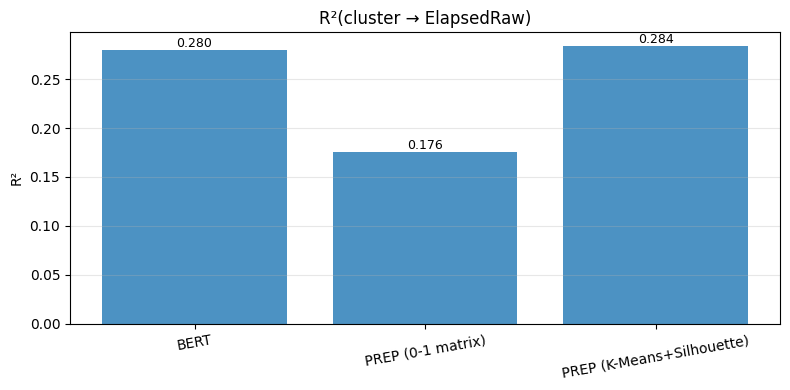

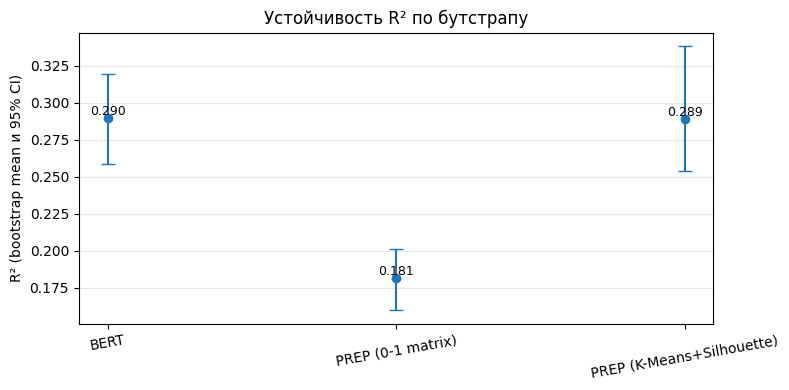

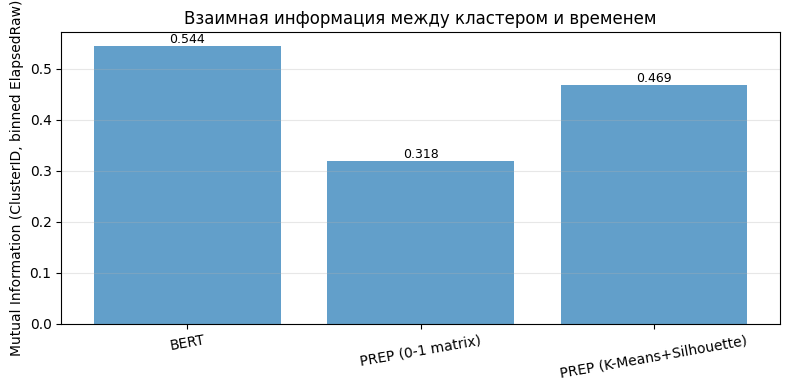

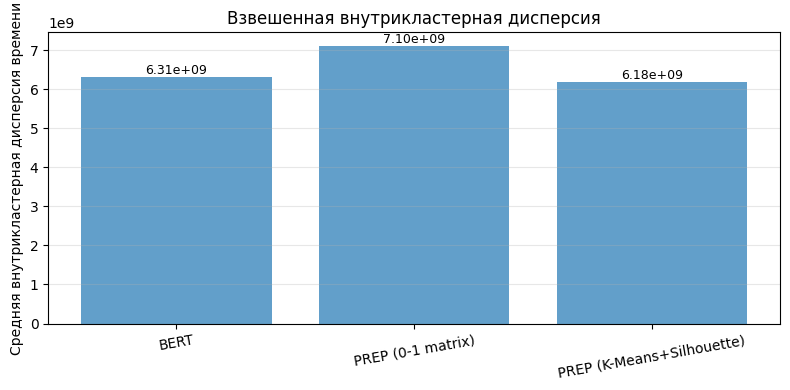

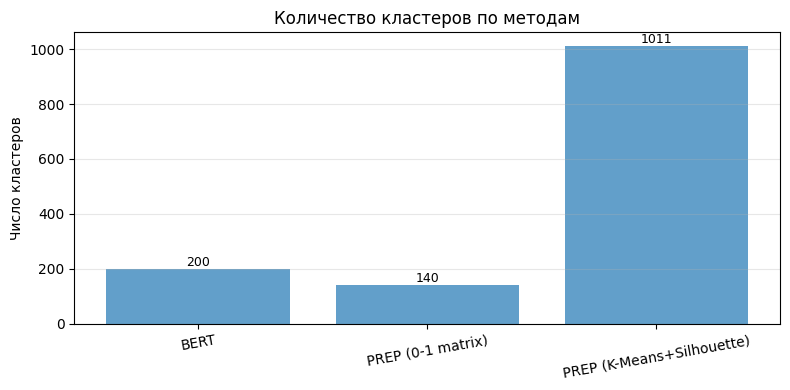

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Используем рассчитанные метрики из предыдущей ячейки
plot_df = summary_df.copy()
plot_df = plot_df.sort_values("Method").reset_index(drop=True)

# Добавляем bootstrap-оценки для R2 и MI
r2_mean_bs, r2_low_bs, r2_high_bs = [], [], []
mi_mean_bs, mi_low_bs, mi_high_bs = [], [], []

for method in plot_df["Method"]:
    bs = all_results[method]["bootstrap"]

    mean_b, low_b, high_b = summarize_bootstrap(bs, "r2_cluster_time")
    r2_mean_bs.append(mean_b)
    r2_low_bs.append(low_b)
    r2_high_bs.append(high_b)

    mean_b, low_b, high_b = summarize_bootstrap(bs, "mutual_info_cluster_time")
    mi_mean_bs.append(mean_b)
    mi_low_bs.append(low_b)
    mi_high_bs.append(high_b)

plot_df["r2_mean_bs"] = r2_mean_bs
plot_df["r2_low_bs"] = r2_low_bs
plot_df["r2_high_bs"] = r2_high_bs
plot_df["mi_mean_bs"] = mi_mean_bs
plot_df["mi_low_bs"] = mi_low_bs
plot_df["mi_high_bs"] = mi_high_bs

x = np.arange(len(plot_df))
labels = plot_df["Method"].tolist()

# --- График 1: R^2 по методам ---
plt.figure(figsize=(8, 4))
bars = plt.bar(x, plot_df["r2_cluster_time"], alpha=0.8)
plt.xticks(x, labels, rotation=10)
plt.ylabel("R²")
plt.title("R²(cluster → ElapsedRaw)")
plt.grid(axis="y", alpha=0.3)
for b, v in zip(bars, plot_df["r2_cluster_time"]):
    plt.text(b.get_x() + b.get_width()/2, b.get_height(), f"{v:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

# --- График 2: R^2 с доверительными интервалами (бутстрап) ---
plt.figure(figsize=(8, 4))
err_low = np.array(plot_df["r2_mean_bs"]) - np.array(plot_df["r2_low_bs"])
err_high = np.array(plot_df["r2_high_bs"]) - np.array(plot_df["r2_mean_bs"])
yerr = np.vstack([err_low, err_high])
plt.errorbar(x, plot_df["r2_mean_bs"], yerr=yerr, fmt="o", capsize=5)
plt.xticks(x, labels, rotation=10)
plt.ylabel("R² (bootstrap mean и 95% CI)")
plt.title("Устойчивость R² по бутстрапу")
plt.grid(axis="y", alpha=0.3)
for xi, v in zip(x, plot_df["r2_mean_bs"]):
    plt.text(xi, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

# --- График 3: Mutual Information ---
plt.figure(figsize=(8, 4))
bars = plt.bar(x, plot_df["mutual_info_cluster_time"], alpha=0.7)
plt.xticks(x, labels, rotation=10)
plt.ylabel("Mutual Information (ClusterID, binned ElapsedRaw)")
plt.title("Взаимная информация между кластером и временем")
plt.grid(axis="y", alpha=0.3)
for b, v in zip(bars, plot_df["mutual_info_cluster_time"]):
    plt.text(b.get_x() + b.get_width()/2, b.get_height(), f"{v:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

# --- График 4: Средняя внутрикластерная дисперсия ---
plt.figure(figsize=(8, 4))
bars = plt.bar(x, plot_df["weighted_mean_intra_var"], alpha=0.7)
plt.xticks(x, labels, rotation=10)
plt.ylabel("Средняя внутрикластерная дисперсия времени")
plt.title("Взвешенная внутрикластерная дисперсия")
plt.grid(axis="y", alpha=0.3)
for b, v in zip(bars, plot_df["weighted_mean_intra_var"]):
    plt.text(b.get_x() + b.get_width()/2, b.get_height(), f"{v:.2e}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

# --- График 5: Число кластеров ---
plt.figure(figsize=(8, 4))
bars = plt.bar(x, plot_df["n_clusters"], alpha=0.7)
plt.xticks(x, labels, rotation=10)
plt.ylabel("Число кластеров")
plt.title("Количество кластеров по методам")
plt.grid(axis="y", alpha=0.3)
for b, v in zip(bars, plot_df["n_clusters"]):
    plt.text(b.get_x() + b.get_width()/2, b.get_height(), f"{int(v)}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

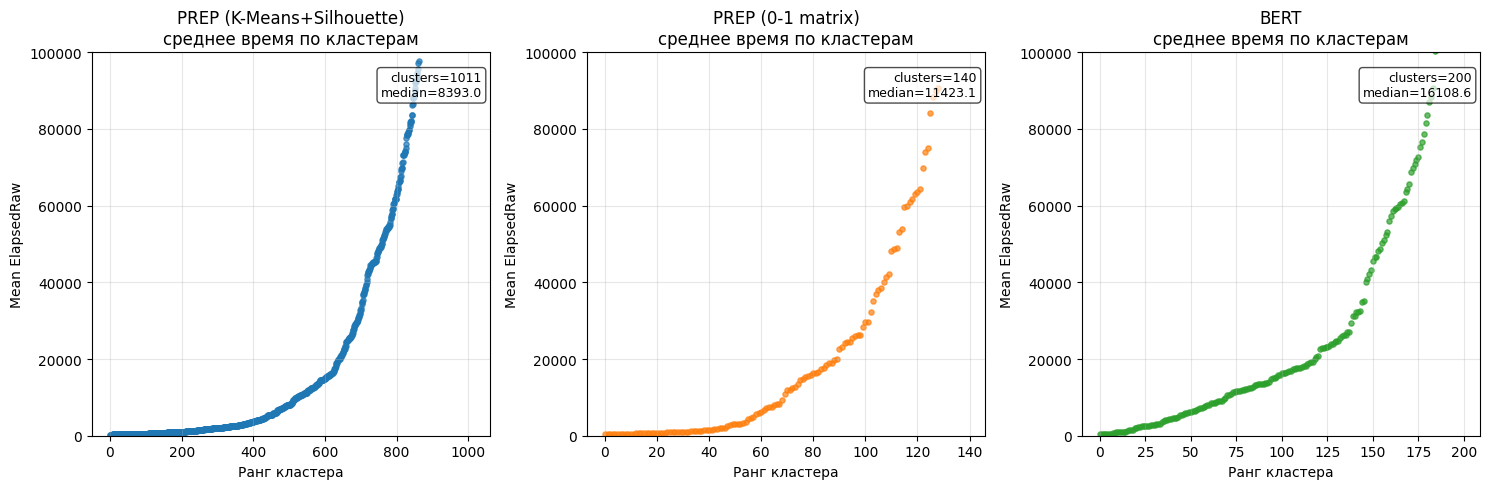

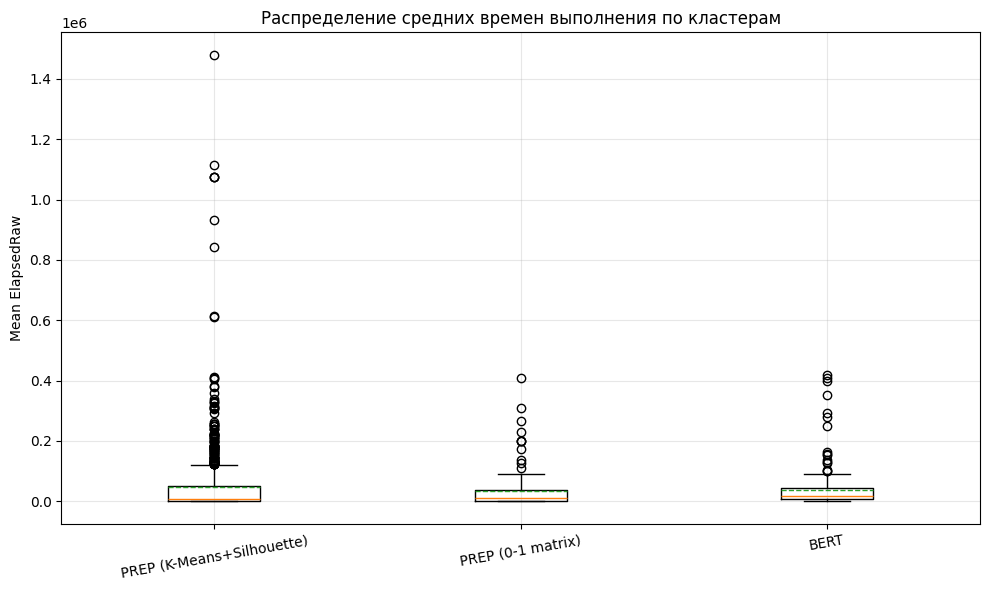

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

INPUT_DIR = "path_processed"
FILES = {
    "PREP (K-Means+Silhouette)": os.path.join(INPUT_DIR, "frccsc_processed_prep_kmeans.csv"),
    "PREP (0-1 matrix)": os.path.join(INPUT_DIR, "frccsc_processed_prep_01.csv"),
    "BERT": os.path.join(INPUT_DIR, "frccsc_processed_bert.csv"),
}

TIME_COL = "ElapsedRaw"
CLUSTER_COL = "PathClusterID"

colors = {
    "PREP (K-Means+Silhouette)": "tab:blue",
    "PREP (0-1 matrix)": "tab:orange",
    "BERT": "tab:green"
}

# === График 1: среднее время выполнения в каждом кластере (ранжирование по возрастанию) ===
plt.figure(figsize=(15, 5))
Y_MAX = 100000

for idx, (name, filepath) in enumerate(FILES.items(), start=1):
    df_local = pd.read_csv(filepath)
    df_local = df_local[[CLUSTER_COL, TIME_COL]].dropna()
    cl_stats = df_local.groupby(CLUSTER_COL)[TIME_COL].mean().reset_index()
    cl_stats = cl_stats.sort_values(TIME_COL).reset_index(drop=True)
    cl_stats["Rank"] = cl_stats.index

    plt.subplot(1, 3, idx)
    plt.scatter(cl_stats["Rank"], cl_stats[TIME_COL], s=14, alpha=0.7, color=colors[name])
    plt.title(f"{name}\nсреднее время по кластерам")
    plt.xlabel("Ранг кластера")
    plt.ylabel("Mean ElapsedRaw")
    plt.ylim(0, Y_MAX)
    plt.grid(alpha=0.3)

    if len(cl_stats) > 0:
        plt.text(
            0.98, 0.95,
            f"clusters={len(cl_stats)}\nmedian={cl_stats[TIME_COL].median():.1f}",
            transform=plt.gca().transAxes,
            ha="right", va="top", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
        )

plt.tight_layout()
plt.show()

# === График 2: распределение средних значений по кластерам ===
plt.figure(figsize=(10, 6))
data_for_boxplot = []
box_labels = []

for name, filepath in FILES.items():
    df_local = pd.read_csv(filepath)
    df_local = df_local[[CLUSTER_COL, TIME_COL]].dropna()
    cl_stats = df_local.groupby(CLUSTER_COL)[TIME_COL].mean()
    data_for_boxplot.append(cl_stats.values)
    box_labels.append(name)

plt.boxplot(data_for_boxplot, labels=box_labels, showmeans=True, meanline=True)
plt.title("Распределение средних времен выполнения по кластерам")
plt.ylabel("Mean ElapsedRaw")
plt.grid(alpha=0.3)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()